# What each group of inputs adds

The static benchmark of notebooks 02 to 07 uses nine inputs in three groups: **geometry** (distance, concrete and wood walls), **channel** (frequency) and **environment** (CO2, humidity, PM2.5, pressure, temperature). Reviewers asked for the contribution of each group and for distance-only and wall-only baselines. Part B asks the same of the groups that the history rungs add.

**Part A, static groups.** One LightGBM, tuned separately on every subset of inputs (30 candidates of a Bayesian search on every tenth training row, validation folds kept), so that a subset is not penalised by hyperparameters chosen for the full set. The per-link mean, the training mean of each link, is the reference without a model. Scores on the hold-out and over the five forward folds: RMSE, and the 99 % margin from one shift with its pinball loss. Differences against the full model and against the per-link mean come with 95 % intervals from resampling days.

**Part B, history groups.** The same paired comparison for every step of the history rungs and every model family, from the saved residuals of notebooks 02 to 15. The 99 % shift is taken from the validation packets at SF7 to SF10, the regime of the hold-out.

In [1]:
import json
import time
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from history_features import RUNGS
from margin_tools import pinball, shift_pooled, day_codes, boot_stat

RANDOM_STATE = 42
TAU = 0.99

In [2]:
# Part A. The chronological split and forward-chaining folds of notebook 00 (fold -1 = first training block, 0-4 = validation blocks, 9 = hold-out)
train = pd.read_csv("Data_Files/train.csv")
train["fold"] = np.load("Data_Files/train_folds.npy")
test = pd.read_csv("Data_Files/test.csv")
test["fold"] = 9
s = pd.concat([train, test], ignore_index=True)
s["t"] = pd.to_datetime(s["time"], utc=True, format="mixed")
fold, PL, link = s["fold"].to_numpy(), s["PL"].to_numpy(), s["device_id"].to_numpy()
day = day_codes(s["t"])
GEOMETRY, CHANNEL, ENVIRONMENT = ["distance", "c_walls", "w_walls"], ["frequency"], ["co2", "humidity", "pm25", "pressure", "temperature"]
subsets = {"distance only": ["distance"],
           "geometry": GEOMETRY,
           "geometry + channel": GEOMETRY + CHANNEL,
           "geometry + environment": GEOMETRY + ENVIRONMENT,
           "geometry + channel + environment": GEOMETRY + CHANNEL + ENVIRONMENT,       # the benchmark
           "environment only": ENVIRONMENT}
full = "geometry + channel + environment"
print(f"{(fold < 9).sum():,} training packets, {(fold == 9).sum():,} on the hold-out; subsets: {list(subsets)}")

2,128,219 training packets, 532,055 on the hold-out; subsets: ['distance only', 'geometry', 'geometry + channel', 'geometry + environment', 'geometry + channel + environment', 'environment only']


In [3]:
# One search per subset (the search space of notebook 05), then the out-of-fold and hold-out predictions
space = {"num_leaves": Integer(8, 96), "max_depth": Integer(1, 10), "learning_rate": Real(0.01, 0.10, prior="log-uniform"), "n_estimators": Integer(100, 1200),
         "min_child_samples": Integer(200, 5000), "min_child_weight": Real(1e-3, 30.0, prior="log-uniform"), "subsample": Real(0.6, 0.9),
         "colsample_bytree": Real(0.4, 0.9), "reg_alpha": Real(1e-4, 50.0, prior="log-uniform"), "reg_lambda": Real(1e-4, 50.0, prior="log-uniform")}
sub = np.flatnonzero(fold < 9)[::10]
cv_sub = [(np.flatnonzero(fold[sub] < k), np.flatnonzero(fold[sub] == k)) for k in range(5)]
base = dict(subsample_freq=1, force_col_wise=True, random_state=RANDOM_STATE, verbose=-1)

def oof_and_test(make, X):
    p = np.full(len(s), np.nan)
    for k in range(5):
        tr, va = fold < k, fold == k
        p[va] = make().fit(X[tr], PL[tr]).predict(X[va])
    p[fold == 9] = make().fit(X[fold < 9], PL[fold < 9]).predict(X[fold == 9])
    return p

pred, best = {}, {}
for name, cols in subsets.items():
    t0 = time.time()
    X = s[cols].to_numpy()
    bs = BayesSearchCV(lgb.LGBMRegressor(n_jobs=4, **base), space, n_iter=30, cv=cv_sub, scoring="neg_root_mean_squared_error", n_jobs=8, n_points=2,
                       random_state=RANDOM_STATE, refit=False, optimizer_kwargs={"n_initial_points": 10})
    bs.fit(X[sub], PL[sub])
    best[name] = dict(bs.best_params_)
    pred[name] = oof_and_test(lambda: lgb.LGBMRegressor(n_jobs=8, **base, **best[name]), X)
    print(f"{name}: search RMSE {-bs.best_score_:.3f} dB, {time.time() - t0:.0f} s")
json.dump(best, open("CV_Results/static_group_best_params.json", "w"), indent=1, default=float)

# the reference without a model: each link's mean over the earlier training packets
mean = np.full(len(s), np.nan)
for k in list(range(5)) + [9]:
    earlier = s[fold < k] if k < 9 else s[fold < 9]
    mean[fold == k] = s.loc[fold == k, "device_id"].map(earlier.groupby("device_id")["PL"].mean())
pred["per-link mean"] = mean
overall = np.full(len(s), np.nan)                       # and one mean for all links: no inputs at all
for k in list(range(5)) + [9]:
    overall[fold == k] = s.loc[fold < k if k < 9 else fold < 9, "PL"].mean()
pred["global mean"] = overall

distance only: search RMSE 6.326 dB, 35 s


geometry: search RMSE 6.323 dB, 58 s


geometry + channel: search RMSE 6.307 dB, 62 s


geometry + environment: search RMSE 6.391 dB, 45 s


geometry + channel + environment: search RMSE 6.322 dB, 64 s


environment only: search RMSE 17.024 dB, 33 s


In [4]:
# Scores: RMSE on the hold-out and over the validation folds, and the 99 % margin from one shift
val, ev = (fold >= 0) & (fold < 9), fold == 9
rmse = lambda e: float(np.sqrt(np.mean(np.square(e))))
rows = []
for name, p in pred.items():
    e = PL - p
    folds = [rmse(e[fold == k]) for k in range(5)]
    c = shift_pooled(e[val], TAU)
    rows.append({"inputs": name, "hold-out RMSE": rmse(e[ev]), "validation RMSE": rmse(e[val]), "fold RMSE mean": np.mean(folds), "fold RMSE sd": np.std(folds, ddof=1),
                 "99 % shift dB": c, "coverage": float((e[ev] <= c).mean()), "pinball x 1000": 1000 * pinball(e[ev], c, TAU).mean()})
scores = pd.DataFrame(rows).set_index("inputs")

# paired differences on the hold-out: against the full model and against the per-link mean
te = np.flatnonzero(ev)
dd = pd.factorize(day[te])[0]
def diff(a, b):
    ea, eb = (PL - pred[a])[te], (PL - pred[b])[te]
    ca, cb = shift_pooled((PL - pred[a])[val], TAU), shift_pooled((PL - pred[b])[val], TAU)
    r = boot_stat(dd, np.column_stack([ea ** 2, eb ** 2, np.ones(len(te))]), lambda T: np.sqrt(T[:, 0] / T[:, 2]) - np.sqrt(T[:, 1] / T[:, 2]))
    l = boot_stat(dd, np.column_stack([pinball(ea, ca, TAU) - pinball(eb, cb, TAU), np.ones(len(te))]), lambda T: 1000 * T[:, 0] / T[:, 1])
    return r + l
for ref in (full, "geometry + channel", "per-link mean"):
    columns = [f"dRMSE vs {ref}", f"lo ({ref})", f"hi ({ref})", f"dpinball vs {ref}", f"lo p ({ref})", f"hi p ({ref})"]
    scores = scores.join(pd.DataFrame({n: diff(n, ref) for n in pred if n != ref}, index=columns).T)
scores.to_csv("CV_Results/static_feature_groups.csv")
display(scores.iloc[:, :7].round(3))
for ref in (full, "geometry + channel", "per-link mean"):
    print(f"hold-out RMSE minus that of {ref}, with the 95 % interval (negative: better)")
    display(scores[[f"dRMSE vs {ref}", f"lo ({ref})", f"hi ({ref})"]].dropna().round(3))

,hold-out RMSE,validation RMSE,fold RMSE mean,fold RMSE sd,99 % shift dB,coverage,pinball x 1000
inputs,,,,,,,
distance only,4.948,6.348,6.309,0.790,17.975,0.998,204.628
geometry,4.993,6.371,6.328,0.829,18.031,0.998,205.473
geometry + channel,4.891,6.303,6.263,0.794,17.837,0.998,203.875
geometry + environment,4.786,6.409,6.370,0.797,17.930,0.998,201.502
geometry + channel + environment,4.865,6.338,6.299,0.787,18.446,0.998,208.994
environment only,15.736,17.154,17.144,0.646,37.796,1.000,398.477
per-link mean,5.035,6.398,6.353,0.853,18.266,0.998,207.585
global mean,16.273,17.364,17.347,0.843,33.999,0.999,357.741


hold-out RMSE minus that of geometry + channel + environment, with the 95 % interval (negative: better)


,dRMSE vs geometry + channel + environment,lo (geometry + channel + environment),hi (geometry + channel + environment)
inputs,,,
distance only,0.083,0.035,0.131
geometry,0.129,0.079,0.180
geometry + channel,0.026,-0.023,0.074
geometry + environment,-0.079,-0.132,-0.026
environment only,10.872,10.429,11.292
per-link mean,0.171,0.113,0.228
global mean,11.409,10.983,11.804


hold-out RMSE minus that of geometry + channel, with the 95 % interval (negative: better)


,dRMSE vs geometry + channel,lo (geometry + channel),hi (geometry + channel)
inputs,,,
distance only,0.057,0.053,0.060
geometry,0.102,0.070,0.134
geometry + environment,-0.105,-0.164,-0.048
geometry + channel + environment,-0.026,-0.074,0.023
environment only,10.845,10.416,11.253
per-link mean,0.144,0.096,0.192
global mean,11.382,10.977,11.768


hold-out RMSE minus that of per-link mean, with the 95 % interval (negative: better)


,dRMSE vs per-link mean,lo (per-link mean),hi (per-link mean)
inputs,,,
distance only,-0.087,-0.133,-0.041
geometry,-0.042,-0.057,-0.026
geometry + channel,-0.144,-0.192,-0.096
geometry + environment,-0.249,-0.323,-0.178
geometry + channel + environment,-0.171,-0.228,-0.113
environment only,10.701,10.231,11.155
global mean,11.238,10.796,11.665


In [5]:
# How much of a difference between subsets is the tuning itself: the search and the fits repeated with other seeds
rows = []
for name in (full, "geometry + environment"):
    X = s[subsets[name]].to_numpy()
    for seed in (1, 2, 3):
        bs = BayesSearchCV(lgb.LGBMRegressor(n_jobs=4, **dict(base, random_state=seed)), space, n_iter=30, cv=cv_sub, scoring="neg_root_mean_squared_error", n_jobs=8, n_points=2,
                           random_state=seed, refit=False, optimizer_kwargs={"n_initial_points": 10})
        bs.fit(X[sub], PL[sub])
        p = oof_and_test(lambda: lgb.LGBMRegressor(n_jobs=8, **dict(base, random_state=seed), **dict(bs.best_params_)), X)
        rows.append(dict(inputs=name, seed=seed, hold_out_rmse=rmse((PL - p)[ev])))
noise = pd.DataFrame(rows)
noise.to_csv("CV_Results/static_tuning_noise.csv", index=False)
print("hold-out RMSE of the same inputs after a repeated search and fit")
display(noise.pivot(index="seed", columns="inputs", values="hold_out_rmse").round(3))
display(noise.groupby("inputs").hold_out_rmse.agg(["mean", "std"]).round(3))

hold-out RMSE of the same inputs after a repeated search and fit


inputs,geometry + channel + environment,geometry + environment
seed,,
1,4.846,4.854
2,4.852,4.903
3,4.831,4.866


,mean,std
inputs,,
geometry + channel + environment,4.843,0.011
geometry + environment,4.874,0.026


In [6]:
# Part B. The history rungs: the rows of notebooks 13 to 17 and the saved residuals of every family
train = pd.read_csv("Data_Files/history_train.csv")
test = pd.read_csv("Data_Files/history_test.csv")
d = pd.concat([train, test], ignore_index=True)
d["t"] = pd.to_datetime(d["t"], utc=True)
d = d.sort_values("t").reset_index(drop=True)
f2 = d["fold"].to_numpy()
H = {k.split()[0]: v for k, v in RUNGS.items()}
ok = (d["y"].notna() & d[H["H7"]].notna().all(axis=1)).to_numpy()
sf = d["SF"].to_numpy().astype(int)
val2, ev2 = ok & (f2 >= 0) & (f2 < 9), ok & (f2 == 9)
position = pd.Series(np.arange(len(d)), index=pd.MultiIndex.from_arrays([d["device_id"], d["t"]]))

def residuals(name):
    out = np.full(len(d), np.nan)
    for split in ("oof", "test"):
        r = pd.read_csv(f"Residuals/residuals_{name}_{split}.csv", usecols=["time", "device_id", "resid_db"])
        i = position.reindex(pd.MultiIndex.from_arrays([r["device_id"], pd.to_datetime(r["time"], utc=True)])).to_numpy()
        found = ~np.isnan(i)
        out[i[found].astype(int)] = r["resid_db"].to_numpy()[found]
    return out

static_name = {"Linear": "MLR", "RF": "RF", "XGB": "XGB", "LGBM": "LGBM", "KNN": "KNN", "ANN": "ANN"}
res = {}
for fam in ("Linear", "RF", "XGB", "LGBM", "KNN", "ANN", "GRU"):
    if fam in static_name:
        res[(fam, "static")] = residuals(static_name[fam])
    for rung in (["H1", "H2", "H3", "H4", "H5", "H6", "H7"] if fam in ("Linear", "LGBM") else ["H1", "H4", "H6", "H7"]):
        res[(fam, rung)] = residuals(f"{fam}_{rung}")
common = ev2 & np.all([np.isfinite(r) for r in res.values()], axis=0)
print(f"{len(res)} models; hold-out packets common to all: {common.sum():,}")

40 models; hold-out packets common to all: 531,983


In [7]:
# Paired differences between consecutive rungs, hold-out, 95 % intervals from resampling days
te = np.flatnonzero(common)
dd = pd.factorize(pd.factorize(d["t"].dt.floor("D"), sort=True)[0][te])[0]
shift = {k: shift_pooled(r[val2 & (sf <= 10) & np.isfinite(r)], TAU) for k, r in res.items()}       # SF7-10 validation packets, the hold-out regime
def step(fam, a, b):
    ea, eb = res[(fam, a)][te], res[(fam, b)][te]
    r = boot_stat(dd, np.column_stack([eb ** 2, ea ** 2, np.ones(len(te))]), lambda T: np.sqrt(T[:, 0] / T[:, 2]) - np.sqrt(T[:, 1] / T[:, 2]))
    l = boot_stat(dd, np.column_stack([pinball(eb, shift[(fam, b)], TAU) - pinball(ea, shift[(fam, a)], TAU), np.ones(len(te))]), lambda T: 1000 * T[:, 0] / T[:, 1])
    return dict(family=fam, step=f"{a} to {b}", dRMSE=r[0], rmse_lo=r[1], rmse_hi=r[2], dpinball=l[0], pin_lo=l[1], pin_hi=l[2])
coarse = [("static", "H1"), ("H1", "H4"), ("H4", "H6"), ("H6", "H7")]
rows = [step(f, a, b) for f in ("Linear", "RF", "XGB", "LGBM", "KNN", "ANN") for a, b in coarse] + [step("GRU", a, b) for a, b in coarse[1:]]
rows += [step("LGBM", a, b) for a, b in [("H1", "H2"), ("H2", "H3"), ("H3", "H4"), ("H4", "H5"), ("H5", "H6"), ("H6", "H7")]]
rows += [step("Linear", a, b) for a, b in [("H1", "H2"), ("H2", "H3"), ("H3", "H4"), ("H4", "H5"), ("H5", "H6"), ("H6", "H7")]]
steps = pd.DataFrame(rows).drop_duplicates(["family", "step"])
steps["excludes zero"] = np.where((steps.rmse_lo > 0) | (steps.rmse_hi < 0), "yes", "no")
steps.to_csv("CV_Results/history_group_steps.csv", index=False)
print("hold-out RMSE of the later rung minus the earlier rung (dB, negative: the added inputs help), with the 95 % interval")
display(steps.set_index(["family", "step"]).round(3))

hold-out RMSE of the later rung minus the earlier rung (dB, negative: the added inputs help), with the 95 % interval


dRMSE  rmse_lo  rmse_hi  dpinball   pin_lo   pin_hi  \
family step                                                                
Linear static to H1 -2.744   -2.958   -2.552  -114.870 -124.460 -108.414   
       H1 to H4     -0.116   -0.125   -0.107    -2.254   -2.460   -2.057   
       H4 to H6     -0.021   -0.022   -0.019    -0.936   -1.065   -0.807   
       H6 to H7      0.000   -0.000    0.001     0.084    0.019    0.142   
RF     static to H1 -2.577   -2.801   -2.371  -116.799 -124.482 -111.073   
       H1 to H4     -0.377   -0.395   -0.358   -10.682  -11.339  -10.035   
       H4 to H6     -0.108   -0.114   -0.102    -0.382   -0.601   -0.158   
       H6 to H7      0.001    0.000    0.002    -0.283   -0.380   -0.182   
XGB    static to H1 -2.489   -2.773   -2.218  -114.559 -128.091 -105.904   
       H1 to H4     -0.391   -0.406   -0.375   -11.494  -12.105  -10.869   
       H4 to H6     -0.126   -0.133   -0.120    -1.528   -1.740   -1.312   
       H6 to H7     -0.002   -0.003   -0.001    -0.530   -0.717   -0.318   
LGBM   static to H1 -2.533   -2.744   -2.337  -114.565 -122.593 -108.779   
       H1 to H4     -0.386   -0.401   -0.370   -11.492  -12.122  -10.874   
       H4 to H6     -0.126   -0.133   -0.119    -1.374   -1.590   -1.163   
       H6 to H7      0.001   -0.000    0.003    -0.646   -0.859   -0.415   
KNN    static to H1 -2.554   -2.843   -2.280  -108.492 -120.340 -100.697   
       H1 to H4     -0.302   -0.316   -0.289    -7.299   -7.691   -6.898   
       H4 to H6      0.002   -0.003    0.008     0.795    0.604    0.992   
       H6 to H7      0.035    0.032    0.038     0.981    0.816    1.157   
ANN    static to H1 -2.587   -3.000   -2.200  -110.121 -132.075  -97.158   
       H1 to H4     -0.503   -0.520   -0.485   -13.925  -14.511  -13.318   
       H4 to H6     -0.079   -0.083   -0.075    -0.608   -0.776   -0.450   
       H6 to H7      0.002   -0.000    0.005    -0.246   -0.331   -0.155   
GRU    H1 to H4     -0.558   -0.574   -0.541   -15.835  -16.350  -15.340   
       H4 to H6     -0.068   -0.073   -0.063    -2.289   -2.530   -2.075   
       H6 to H7      0.020    0.017    0.022     0.536    0.370    0.714   
LGBM   H1 to H2     -0.250   -0.262   -0.238    -5.910   -6.280   -5.534   
       H2 to H3     -0.004   -0.005   -0.003    -0.180   -0.240   -0.121   
       H3 to H4     -0.132   -0.138   -0.126    -5.402   -5.782   -5.025   
       H4 to H5     -0.129   -0.136   -0.122    -1.572   -1.783   -1.365   
       H5 to H6      0.003    0.002    0.004     0.199    0.140    0.274   
Linear H1 to H2     -0.109   -0.118   -0.101    -2.340   -2.550   -2.133   
       H2 to H3     -0.000   -0.000   -0.000    -0.047   -0.059   -0.035   
       H3 to H4     -0.006   -0.006   -0.006     0.133    0.114    0.151   
       H4 to H5     -0.020   -0.022   -0.019    -0.865   -0.982   -0.749   
       H5 to H6     -0.001   -0.001   -0.000    -0.071   -0.090   -0.051   

                    excludes zero  
family step                        
Linear static to H1           yes  
       H1 to H4               yes  
       H4 to H6               yes  
       H6 to H7                no  
RF     static to H1           yes  
       H1 to H4               yes  
       H4 to H6               yes  
       H6 to H7               yes  
XGB    static to H1           yes  
       H1 to H4               yes  
       H4 to H6               yes  
       H6 to H7               yes  
LGBM   static to H1           yes  
       H1 to H4               yes  
       H4 to H6               yes  
       H6 to H7                no  
KNN    static to H1           yes  
       H1 to H4               yes  
       H4 to H6                no  
       H6 to H7               yes  
ANN    static to H1           yes  
       H1 to H4               yes  
       H4 to H6               yes  
       H6 to H7                no  
GRU    H1 to H4               yes  
       H4 to H6               yes  
       H6 to H7               yes  
LGBM   H1 to

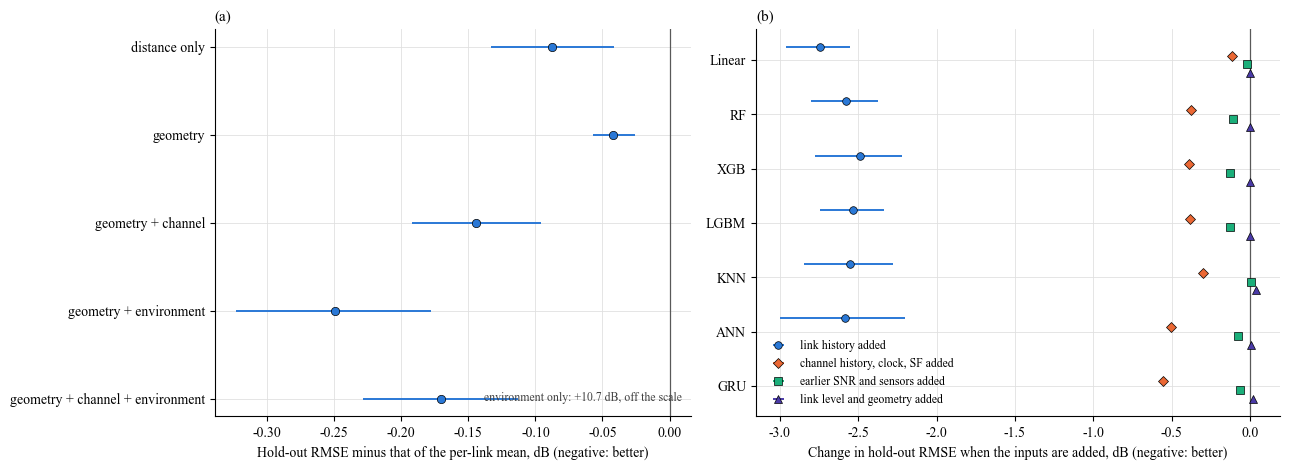

In [8]:
# Figure: static groups against the per-link mean, and the steps of the history rungs
plt.rcParams.update({"font.family": "serif", "font.serif": ["Times New Roman", "DejaVu Serif"], "font.size": 10})
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1, 1.1]})
order = ["distance only", "geometry", "geometry + channel", "geometry + environment", full]
ref = "per-link mean"
for i, n in enumerate(order):
    r = scores.loc[n]
    ax[0].errorbar(r[f"dRMSE vs {ref}"], len(order) - 1 - i, xerr=[[r[f"dRMSE vs {ref}"] - r[f"lo ({ref})"]], [r[f"hi ({ref})"] - r[f"dRMSE vs {ref}"]]], fmt="o", color="#2a78d6", ms=6, mec="black", mew=0.5, lw=1.4)
ax[0].axvline(0, color="0.35", lw=0.9)
ax[0].text(0.98, 0.04, f"environment only: {scores.loc['environment only', f'dRMSE vs {ref}']:+.1f} dB, off the scale", transform=ax[0].transAxes, ha="right", fontsize=8.5, color="0.25")
ax[0].set_yticks(range(len(order)), order[::-1])
ax[0].set_xlabel("Hold-out RMSE minus that of the per-link mean, dB (negative: better)")
colours = {"static to H1": ("#2a78d6", "o"), "H1 to H4": ("#eb6834", "D"), "H4 to H6": ("#1baf7a", "s"), "H6 to H7": ("#4a3aa7", "^")}
labels = {"static to H1": "link history added", "H1 to H4": "channel history, clock, SF added", "H4 to H6": "earlier SNR and sensors added", "H6 to H7": "link level and geometry added"}
fams = ["Linear", "RF", "XGB", "LGBM", "KNN", "ANN", "GRU"]
for j, (stp, (colour, marker)) in enumerate(colours.items()):
    sel = steps[steps.step == stp].set_index("family")
    for i, f in enumerate(fams):
        if f in sel.index:
            r = sel.loc[f]
            ax[1].errorbar(r.dRMSE, len(fams) - 1 - i + (1.5 - j) * 0.16, xerr=[[r.dRMSE - r.rmse_lo], [r.rmse_hi - r.dRMSE]], fmt=marker, color=colour, ms=5.5, mec="black", mew=0.5, lw=1.4,
                           label=labels[stp] if i == 0 else None)
ax[1].axvline(0, color="0.35", lw=0.9)
ax[1].set_yticks(range(len(fams)), fams[::-1])
ax[1].set_xlabel("Change in hold-out RMSE when the inputs are added, dB (negative: better)")
ax[1].legend(frameon=False, loc="lower left", fontsize=8.5)
for a_, tag in zip(ax, "ab"):
    a_.grid(color="0.88", lw=0.6)
    a_.set_axisbelow(True)
    a_.set_title(f"({tag})", loc="left", fontsize=11)
    for sp in ("top", "right"):
        a_.spines[sp].set_visible(False)
fig.tight_layout()
fig.savefig("Figures/feature_groups.png", dpi=300, bbox_inches="tight")
plt.show()

**Reading of the results.**

**Part A, static inputs.**
* **Every subset that holds the geometry lands within 0.25 dB of the per-link mean.** Hold-out RMSE is 4.79 to 4.99 dB against 5.04 dB for the per-link mean, and the intervals from resampling days exclude zero. The whole range is as large as the noise of the tuning: repeating the search and the fits for the same inputs moves the hold-out RMSE by up to 0.12 dB, with a standard deviation of 0.01 to 0.03 dB over three repeats.
* **Distance only is a control.** With six links it takes six values, so it is the per-link mean up to the shrinkage of the trees, and it still lands 0.09 dB below it. Differences of that size are not resolved by this design.
* **The environment adds nothing resolvable.** The full model minus geometry and channel is -0.03 dB, with an interval from -0.07 to +0.02. The sensors alone are useless for the level: the RMSE is 15.7 dB against 16.3 dB for one mean over all links and 5.0 dB for the per-link mean, so they remove 6.5 % of the variance around one mean for all links where the link identity removes 90 %.
* **No subset improves the margin.** The 99 % shift from one pooled calibration is 17.8 to 18.4 dB for every subset with the geometry, 18.3 dB for the per-link mean, and the pinball losses lie within 4 % of each other.

**Part B, the inputs of the history rungs.**
* **The link's history is the step.** Adding it to the static inputs lowers the RMSE by 2.5 to 2.7 dB in every family, with intervals about 0.5 dB wide.
* **Within the history, the LightGBM gains from the same-channel history (-0.25 dB), the spreading factor (-0.13 dB) and the SNR of earlier packets (-0.13 dB).** The clock (-0.004 dB), the sensors (+0.003 dB) and the link level with the geometry (+0.001 dB) add nothing. The other families show the same pattern in the combined steps; the kNN gets worse by 0.04 dB with the link level and the geometry, the usual price of inputs that carry no information in a distance-based method.
* **Limits of the intervals.** They cover the sampling of the hold-out and not the training noise, which is 0.01 to 0.1 dB. Steps of 0.1 dB and more are resolved; steps of a few thousandths of a dB are statistically different from zero in the paired comparison and practically zero.